**Import** **Libraries**

In [3]:
%pip install seaborn
%pip install folium

Note: you may need to restart the kernel to use updated packages.

   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]

Note: you may need to restart the kernel to use updated packages.


2.3.3


In [4]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [13]:
df= pd.read_csv('C:/Users/user/Downloads/archive (1)/credit_risk_dataset.csv')
print(df.head(3))

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  
1                 0.10                         N                           2  
2                 0.57                         N                           3  


# DATASET DESCRIPTION
### Feature Name>   	                              Description
### person_age>     	                           Age
### person_income>                                  Annual Income
### person_home_ownership>	                       Home ownership
### person_emp_length>     	                       Employment length (in years)
### loan_intent>             	                   Loan intent
### loan_grade>	                                   Loan grade
### loan_amnt>	                                   Loan amount
### loan_int_rate>	                                Interest rate
### loan_status>	                                   Loan status (0 is non default 1 is default)
### loan_percent_income>	                           Percent income
### cb_person_default_on_file>	                   Historical default
### cb_preson_cred_hist_length>	                   Credit history length

# Performing data cleaning

In [59]:
print(df.duplicated().sum()) #check for duplicates

165


In [60]:
df = df.drop_duplicates() #deleting Duplicates

In [61]:
print(df.duplicated().sum())

0


In [62]:
print(df.isnull().sum()) #check for empty rows

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
Income Group                     0
Loan Amount Group                0
Interest Rate Group           3095
Percent Income Group             0
dtype: int64


In [65]:
df['person_emp_length'].nlargest(3) #checking outliers 

0        123.0
210      123.0
32355     41.0
Name: person_emp_length, dtype: float64

In [68]:
df['person_age'].nlargest(10)


81       144
183      144
32297    144
575      123
747      123
32416     94
32506     84
32422     80
32355     78
32534     76
Name: person_age, dtype: int64

In [69]:
df = df.drop(df[df['person_emp_length'] > 1].index)

In [70]:
df=df.drop(df[df['person_age']>100].index)

In [71]:
df['person_emp_length']=df['person_emp_length'].fillna(df['person_emp_length'].mean())
df['loan_int_rate']=df['loan_int_rate'].fillna(df['loan_int_rate'].mean())


## Q1) What is the overall loan default rate?

In [72]:
default_rate = df['loan_status'].mean() * 100

print(f"Overall Loan Default Rate: {default_rate:.2f}%")

Overall Loan Default Rate: 28.30%


In [73]:
total_loans = len(df)

defaulted_loans = (df['loan_status'] == 1).sum()

default_rate = (defaulted_loans / total_loans) * 100

print("Total loans:", total_loans)
print("Defaulted loans:", defaulted_loans)
print(f"Overall loan default rate: {default_rate:.2f}%")

Total loans: 7870
Defaulted loans: 2227
Overall loan default rate: 28.30%


## Q2) Which loan grades have the highest default rates?

In [74]:
grade_analysis = df.groupby('loan_grade').agg(
    Total_Loans=('loan_status', 'count'),
    Defaults=('loan_status', 'sum'),
    Default_Rate=('loan_status', 'mean')
)

grade_analysis['Default_Rate'] = grade_analysis['Default_Rate'] * 100

grade_analysis = grade_analysis.sort_values(
    'Default_Rate',
    ascending=False
)

print(grade_analysis)

            Total_Loans  Defaults  Default_Rate
loan_grade                                     
G                    10        10    100.000000
F                    72        62     86.111111
E                   265       223     84.150943
D                   874       690     78.947368
C                  1704       396     23.239437
B                  2450       496     20.244898
A                  2495       350     14.028056


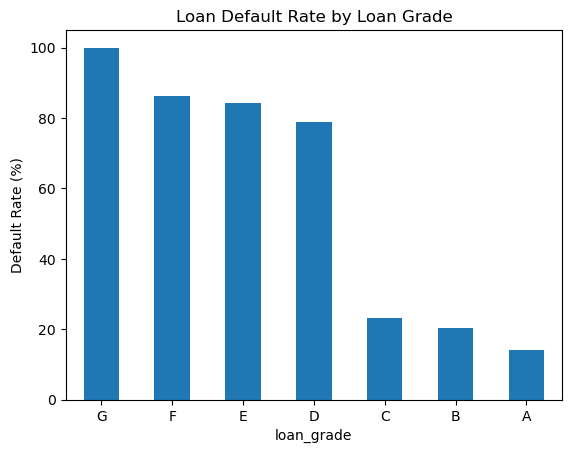

In [75]:
import matplotlib.pyplot as plt

grade_analysis['Default_Rate'].plot(kind='bar')

plt.title('Loan Default Rate by Loan Grade')
plt.xlabel('loan_grade')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

## (Q3) How does default rate vary by loan intent?

In [76]:
intent_analysis = df.groupby('loan_intent').agg(
    Total_Loans=('loan_status', 'count'),
    Defaults=('loan_status', 'sum'),
    Default_Rate=('loan_status', 'mean')
)

intent_analysis['Default_Rate'] = intent_analysis['Default_Rate'] * 100

intent_analysis = intent_analysis.sort_values(
    'Default_Rate',
    ascending=False
)

print(intent_analysis)

                   Total_Loans  Defaults  Default_Rate
loan_intent                                           
HOMEIMPROVEMENT            867       340     39.215686
DEBTCONSOLIDATION         1269       404     31.836091
PERSONAL                  1298       384     29.583975
MEDICAL                   1477       406     27.488152
EDUCATION                 1588       374     23.551637
VENTURE                   1371       319     23.267688


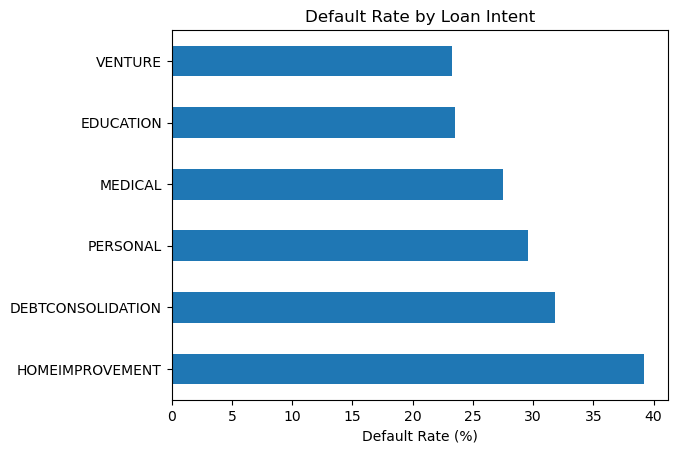

In [77]:
intent_analysis['Default_Rate'].plot(kind='barh')

plt.title('Default Rate by Loan Intent')
plt.ylabel('')
plt.xlabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

# (Q4) Does annual income influence loan default?

In [78]:
df['Income Group'] = pd.qcut(
    df['person_income'],
    q=5,
    labels=['Lowest', 'Low', 'Medium', 'High', 'Highest']
)

In [79]:
income_analysis = df.groupby('Income Group', observed=True).agg(
    Total_Loans=('loan_status', 'count'),
    Defaults=('loan_status', 'sum'),
    Default_Rate=('loan_status', 'mean')
)

income_analysis['Default_Rate']=income_analysis['Default_Rate'] * 100
income_analysis= income_analysis.sort_values('Default_Rate', 
                                      ascending= False)

print(income_analysis)

              Total_Loans  Defaults  Default_Rate
Income Group                                     
Lowest               1854       942     50.809061
Low                  1325       420     31.698113
Medium               1619       378     23.347746
High                 1498       261     17.423231
Highest              1574       226     14.358323


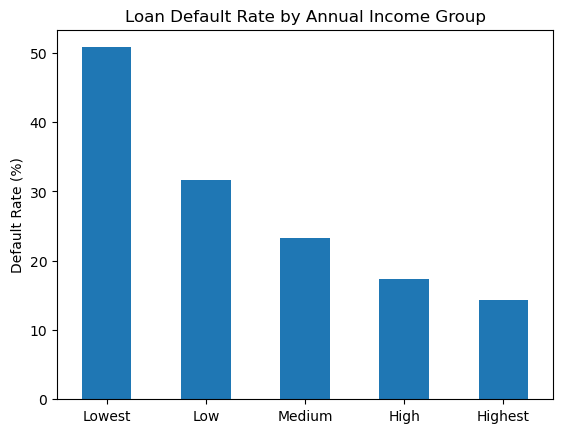

In [80]:

income_analysis['Default_Rate'].plot(kind='bar')

plt.title('Loan Default Rate by Annual Income Group')
plt.xlabel('')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

## (Q5) How does loan amount affect default probability?

In [81]:
df['Loan Amount Group'] = pd.qcut(
    df['loan_amnt'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

In [82]:
loan_amount_analysis = df.groupby(
    'Loan Amount Group',
    observed=True
).agg(
    Total_Loans=('loan_status', 'count'),
    Defaults=('loan_status', 'sum'),
    Default_Rate=('loan_status', 'mean')
)

loan_amount_analysis['Default_Rate']= loan_amount_analysis['Default_Rate'] * 100
loan_amount_analysis= loan_amount_analysis.sort_values( 'Default_Rate', ascending= False)

print(loan_amount_analysis)

                   Total_Loans  Defaults  Default_Rate
Loan Amount Group                                     
Very High                 1573       581     36.935791
Very Low                  1574       460     29.224905
High                      1569       431     27.469726
Medium                    1287       326     25.330225
Low                       1867       429     22.978040


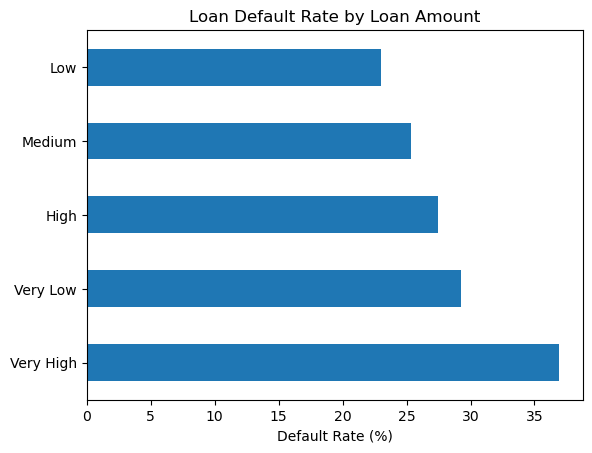

In [83]:
loan_amount_analysis['Default_Rate'].plot(kind='barh')

plt.title('Loan Default Rate by Loan Amount')
plt.ylabel('')
plt.xlabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

## Check the relationship statistically

In [84]:
correlation = df['loan_amnt'].corr(df['loan_status'])

print(f"Correlation: {correlation:.3f}")

Correlation: 0.087


## (Q6) Does interest rate have a relationship with default?

In [85]:
df['Interest Rate Group'] = pd.qcut(
    df['loan_int_rate'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

In [86]:
interest_analysis = df.groupby(
    'Interest Rate Group',
    observed=True
).agg(
    Total_Loans=('loan_status', 'count'),
    Defaults=('loan_status', 'sum'),
    Default_Rate=('loan_status', 'mean')
)

interest_analysis['Default_Rate']=interest_analysis['Default_Rate'] * 100
interest_analysis= interest_analysis.sort_values('Default_Rate', ascending= False)

print(interest_analysis)

                     Total_Loans  Defaults  Default_Rate
Interest Rate Group                                     
Very High                   1550       974     62.838710
High                        1548       373     24.095607
Medium                      1607       383     23.833230
Low                         1485       266     17.912458
Very Low                    1680       231     13.750000


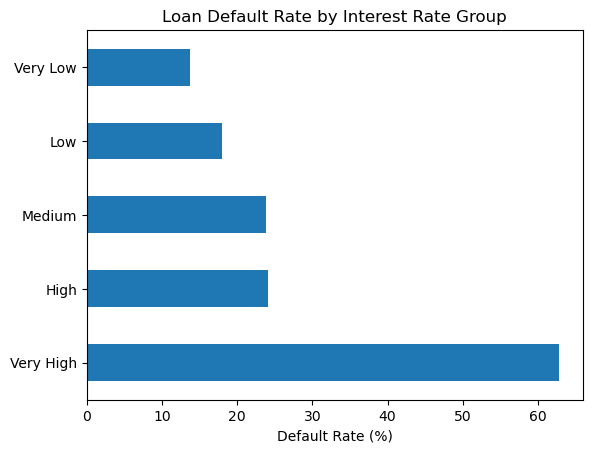

In [87]:
interest_analysis['Default_Rate'].plot(kind='barh')

plt.title('Loan Default Rate by Interest Rate Group')
plt.ylabel('')
plt.xlabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

# (Q7) How does percent income affect default risk?

In [88]:
df['Percent Income Group'] = pd.qcut(
    df['loan_percent_income'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

In [89]:
income_percent_analysis = df.groupby(
    'Percent Income Group',
    observed=True
).agg(
    Total_Loans=('loan_status', 'count'),
    Defaults=('loan_status', 'sum'),
    Default_Rate=('loan_status', 'mean')
)

income_percent_analysis['Default_Rate']=income_percent_analysis['Default_Rate'] * 100
income_percent_analysis= income_percent_analysis.sort_values('Default_Rate', ascending=False)

print(income_percent_analysis)

                      Total_Loans  Defaults  Default_Rate
Percent Income Group                                     
Very High                    1552       981     63.208763
High                         1535       424     27.622150
Medium                       1446       308     21.300138
Low                          1637       264     16.127062
Very Low                     1700       250     14.705882


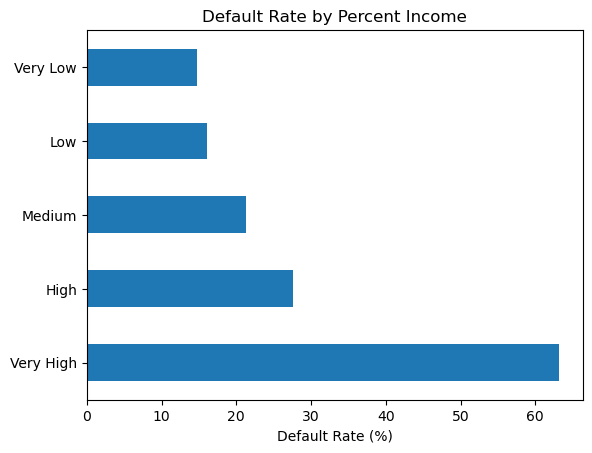

In [90]:
income_percent_analysis['Default_Rate'].plot(kind='barh')

plt.title('Default Rate by Percent Income')
plt.ylabel('')
plt.xlabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

# (Q8) Are borrowers with historical defaults more likely to default again using python?  

In [91]:
historical_default_analysis = df.groupby('cb_person_default_on_file').agg(
    Total_Loans=('loan_status', 'count'),
    Current_Defaults=('loan_status', 'sum'),
    Default_Rate=('loan_status', 'mean')
)

historical_default_analysis['Default_Rate'] =historical_default_analysis['Default_Rate']* 100
historical_default_analysis= historical_default_analysis.sort_values('Default_Rate', ascending= False)

print(historical_default_analysis)

                           Total_Loans  Current_Defaults  Default_Rate
cb_person_default_on_file                                             
Y                                 1476               687     46.544715
N                                 6394              1540     24.085080


In [92]:
for status, row in historical_default_analysis.iterrows():
    print(
        f"Historical default = {status}: "
        f"{row['Default_Rate']:.2f}% current default rate"
    )

Historical default = Y: 46.54% current default rate
Historical default = N: 24.09% current default rate


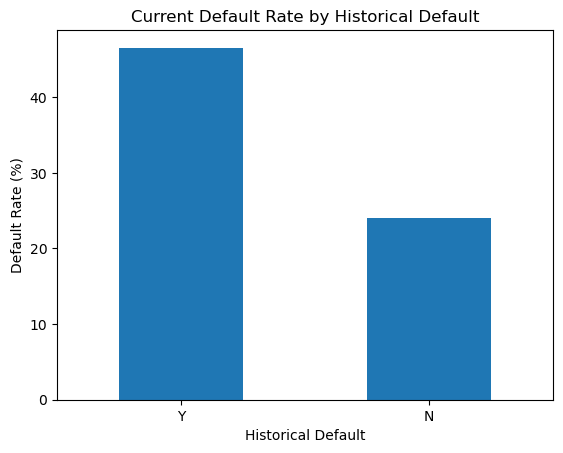

In [93]:
historical_default_analysis['Default_Rate'].plot(kind='bar')

plt.title('Current Default Rate by Historical Default')
plt.xlabel('Historical Default')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()